# Temporal analysis of Fake News/Politically Charged links


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import powerlaw


In [3]:
# Load the datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

## Extract politically charged messages


In [4]:
# Check possible values for fake_information column in df_links
print(df_links['fake_information'].unique())

<StringArray>
[             nan,        'unknown',           'high',          'Mixed',
            'low',           'True', 'mostly factual',      'very high',
          'mixed',       'very-low']
Length: 10, dtype: str


In [5]:
# Gather the messages with misinformation
misinformation_levels = ['Mixed', 'low', 'True', 'mixed', 'very-low']
# Gather messages with those values in the "fake information" column
misinformation_messages = df_links[df_links['fake_information'].isin(misinformation_levels)]
# Gather messages with "high" or "very-high" misinformation score
informative_messages = df_links[df_links['fake_information'].isin(['high', 'very high', np.nan])] # idk if I should add nan values, but I will do it just in case



In [ ]:

misinformation_messages.head()

<class 'pandas.DataFrame'>
Index: 157 entries, 103 to 2077
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   157 non-null    str    
 1   links                  47 non-null     str    
 2   platform               47 non-null     str    
 3   username               47 non-null     str    
 4   sender_id              157 non-null    int64  
 5   sender_username        103 non-null    str    
 6   sender_name            155 non-null    str    
 7   sender_type            47 non-null     str    
 8   count                  47 non-null     float64
 9   username_count         47 non-null     float64
 10  political              31 non-null     str    
 11  type                   157 non-null    str    
 12  political_orientation  102 non-null    str    
 13  fake_information       157 non-null    str    
 14  is_forwarded           110 non-null    object 
 15  fwd_from_channel_id

,date,links,platform,username,sender_id,sender_username,sender_name,sender_type,count,username_count,political,type,political_orientation,fake_information,is_forwarded,fwd_from_channel_id,fwd_from_channel_name
103,2024-11-02T07:49:30+00:00,https://x.com/okdiario/status/1852342806922043...,twitter,okdiario,702737014,semillavf,VF,user,1.0,7.0,political,extracted_link,far-right,Mixed,NaN,NaN,NaN
106,2024-11-02T08:53:47+00:00,https://gaceta.es/espana/mazon-y-marlaska-pide...,other,gaceta,524281487,SocialPermanent,: Vic.,user,1.0,2.0,political,extracted_link,far-right,low,NaN,NaN,NaN
108,2024-11-02T10:15:06+00:00,https://t.me/rubengisbertoficial/2008,telegram,rubengisbertoficial,1696509502,Bordallin,Irene,user,1.0,10.0,NaN,extracted_link,anti-establisment,True,NaN,NaN,NaN
119,2024-11-02T12:27:53+00:00,https://www.larazon.es/sociedad/acertada-predi...,other,larazon,7046448,nbseks,diana,user,1.0,4.0,political,extracted_link,right,Mixed,NaN,NaN,NaN
139,2024-11-02T16:33:21+00:00,https://cnnespanol.cnn.com/2024/11/01/inundaci...,other,cnn,7094531229,NaN,CarlosM,user,2.0,2.0,political,extracted_link,center-left,Mixed,NaN,NaN,NaN


In [7]:
df.head()

,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",NaN,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",NaN,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,NaN,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],NaN,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,NaN,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [ ]:
import pandas as pd

# Work on copies to avoid mutating original dataframes
mis = misinformation_messages.copy()
full = df.copy()

# 1) Normalize sender_id type
mis["sender_id"] = pd.to_numeric(mis["sender_id"], errors="coerce").astype("Int64")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
mis["date_dt"] = pd.to_datetime(mis["date"], utc=True, errors="coerce")
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")


# 3) Exact match on sender_id + date
matches = mis.merge(
    full,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_misinfo", "_df")
)

# 4) Found vs not found (df has column `id`)
found = matches[matches["id"].notna()]
not_found = matches[matches["id"].isna()]

print("Found:", len(found))
print("Not found:", len(not_found))

# Preview matched rows
found[["date_dt", "sender_id", "links", "id"]].head()

Found: 182
Not found: 0


,date_dt,sender_id,links,id
0,2024-11-02 07:49:30+00:00,702737014,https://x.com/okdiario/status/1852342806922043...,8361
1,2024-11-02 08:53:47+00:00,524281487,https://gaceta.es/espana/mazon-y-marlaska-pide...,8556
2,2024-11-02 10:15:06+00:00,1696509502,https://t.me/rubengisbertoficial/2008,8925
3,2024-11-02 12:27:53+00:00,7046448,https://www.larazon.es/sociedad/acertada-predi...,9660
4,2024-11-02 16:33:21+00:00,7094531229,https://cnnespanol.cnn.com/2024/11/01/inundaci...,11195


## Temporal analysis of messages one hour after misinformation link

Number of waiting times: 1411
Min/median/max waiting time (secs): 1.0 1559.0 3591.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


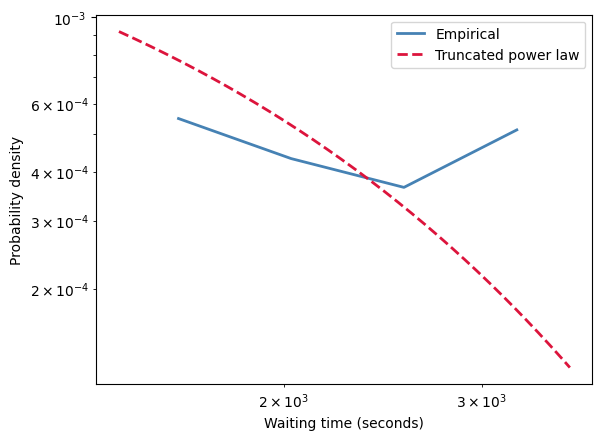

Fitted truncated power law:


In [20]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full dataset with parsed timestamps
full = df.copy()
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full["topic_name"].eq(source["topic_name"])
    within_window = full["date_dt"].gt(source["date_dt"]) & full["date_dt"].le(source["date_dt"] + window)

    later_messages = full.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

Number of waiting times: 1411
Min/median/max waiting time (secs): 1.0 1559.0 3591.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


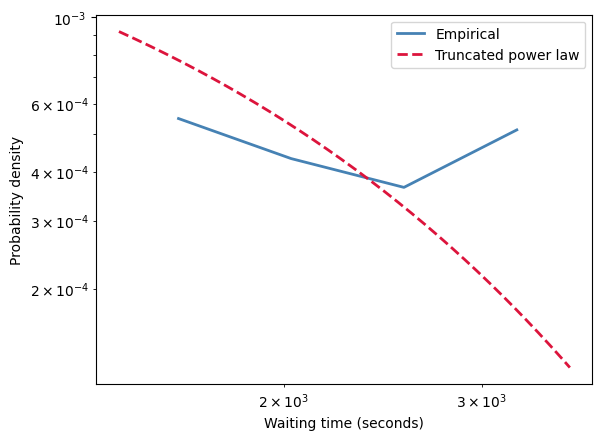

Fitted truncated power law:


In [22]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full dataset with parsed timestamps
full = df.copy()
full["date_dt"] = pd.to_datetime(full["date"], utc=True, errors="coerce")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")
full = full.dropna(subset=["date_dt", "topic_name"])

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full["topic_name"].eq(source["topic_name"])
    within_window = full["date_dt"].gt(source["date_dt"]) & full["date_dt"].le(source["date_dt"] + window)

    later_messages = full.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

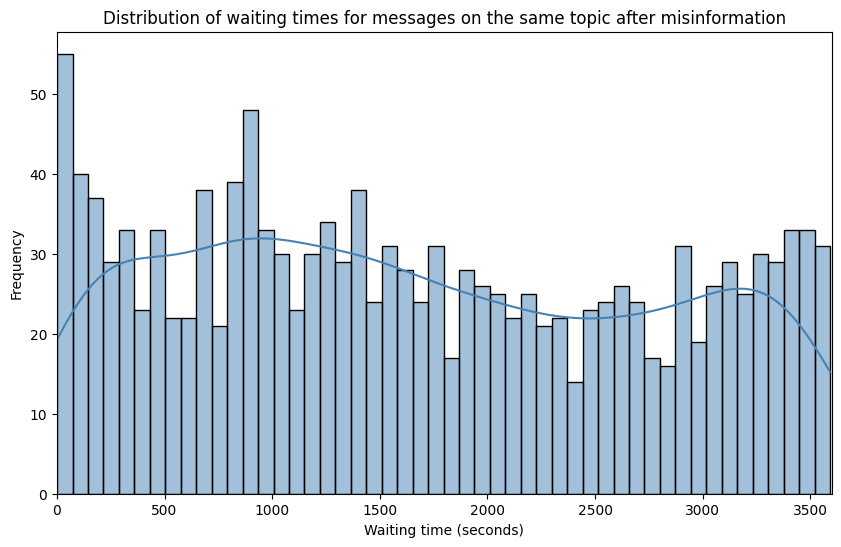

In [24]:
# Obtain the distribution of waiting times
waiting_times = waiting_times_df["wait_seconds"].to_numpy()
waiting_times = waiting_times[waiting_times > 0]
# Plot the distribution of waiting times
plt.figure(figsize=(10, 6))
sns.histplot(waiting_times, bins=50, kde=True, color="steelblue")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of waiting times for messages on the same topic after misinformation")
plt.xlim(0, 3600)  # Limit x-axis to 1 hour
plt.show()


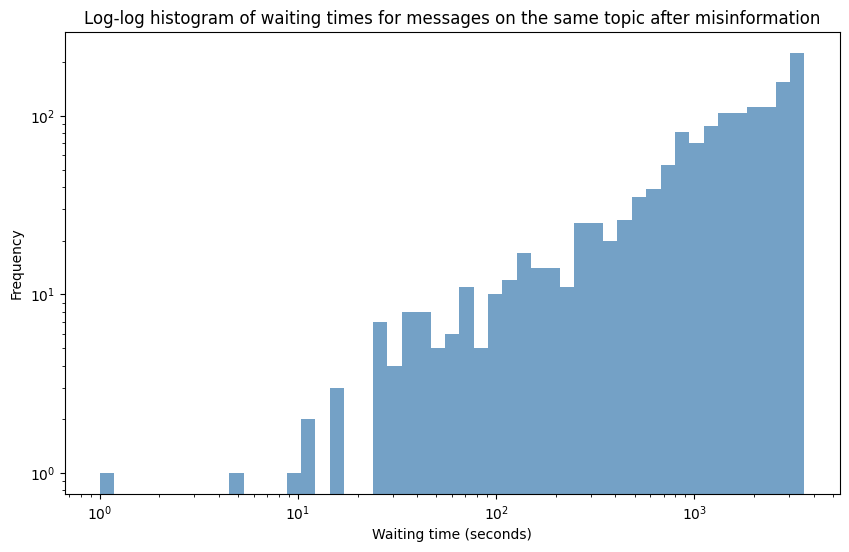

In [25]:
# histogram of waiting times with log-log scale and logarithmic bins
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(waiting_times.min()), np.log10(waiting_times.max()), 50)
sns.histplot(waiting_times, bins=bins, kde=False, color="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Log-log histogram of waiting times for messages on the same topic after misinformation")
plt.show()  

POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 2.8899
xmin: 1427.0000
sigma: 0.0680
Data points above xmin: 773 / 1411 (54.78%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -21.2538, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -11.2196, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -21.2341, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.1888
KS p-value (tail): 6.16307e-25


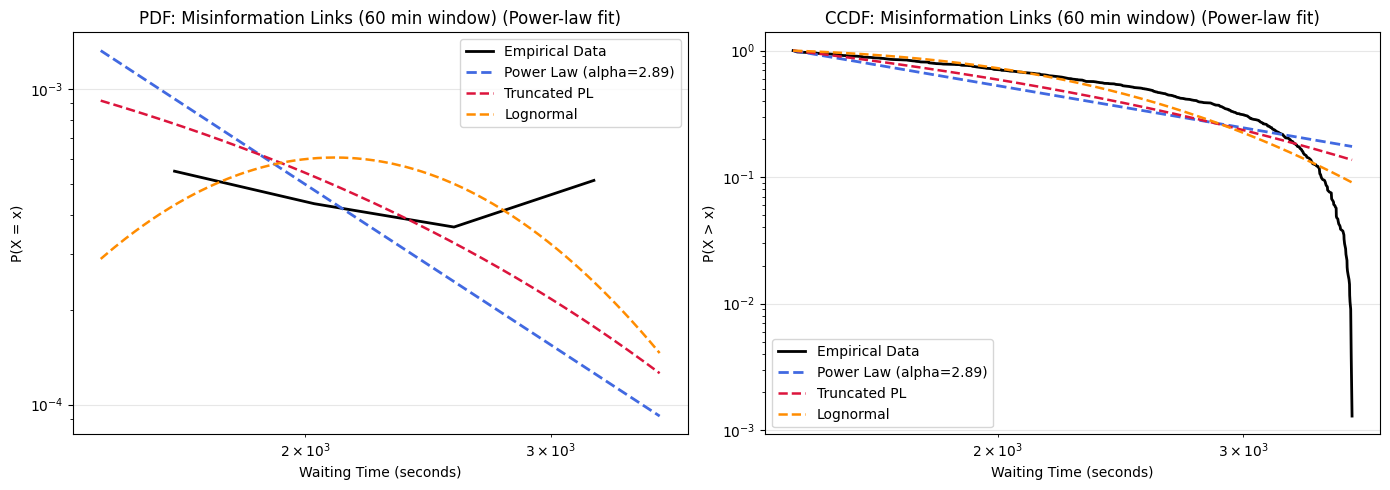

POWER LAW FIT RESULTS: Informative Links (60 min window)
alpha: 2.9991
xmin: 1516.0000
sigma: 0.0246
Data points above xmin: 6605 / 12823 (51.51%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; cons


Power Law vs Truncated PL:
  R = -78.5951, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -40.3226, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -78.5714, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.2140
KS p-value (tail): 2.94296e-266


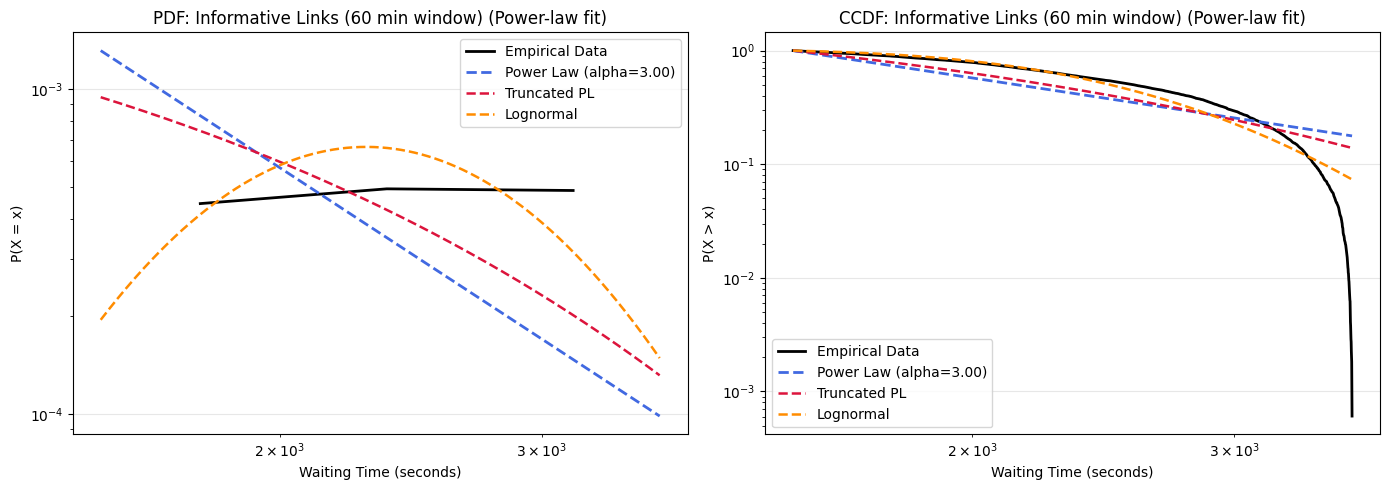

In [ ]:
# Plain power-law fit for both groups

def fit_power_law_report(waiting_times_input, label, discrete=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    print("=" * 70)
    print(f"POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_pl:.4f}")
    print(f"xmin: {xmin_pl:.4f}")
    print(f"sigma: {sigma_pl:.4f}")
    n_tail_pl = int(np.sum(data_pl >= xmin_pl))
    print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

    print("\n" + "=" * 70)
    print("POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
        ("power_law", "lognormal", "Power Law vs Lognormal"),
        ("power_law", "exponential", "Power Law vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        ks_stat_pl, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (power law): {ks_pl:.4f}")
    print(f"KS p-value (tail): {ks_p_pl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
    fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
    fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label} (Power-law fit)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
    fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
    fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label} (Power-law fit)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_pl


fit_mis_pl = fit_power_law_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)
fit_inf_pl = fit_power_law_report(inf_waiting_times, "Informative Links (60 min window)", discrete=True)

## Temporal analysis of messages one hour after informative links

In [26]:
import pandas as pd

# Work on copies to avoid mutating original dataframes
inf = informative_messages.copy()
full_inf = df.copy()

# 1) Normalize sender_id type
inf["sender_id"] = pd.to_numeric(inf["sender_id"], errors="coerce").astype("Int64")
full_inf["sender_id"] = pd.to_numeric(full_inf["sender_id"], errors="coerce").astype("Int64")

# 2) Normalize date to UTC datetime
inf["date_dt"] = pd.to_datetime(inf["date"], utc=True, errors="coerce")
full_inf["date_dt"] = pd.to_datetime(full_inf["date"], utc=True, errors="coerce")


# 3) Exact match on sender_id + date
matches = inf.merge(
    full_inf,
    on=["sender_id", "date_dt"],
    how="left",
    suffixes=("_informative", "_df")
)

# 4) Found vs not found (df has column `id`)
found_inf = matches[matches["id"].notna()]
not_found_inf = matches[matches["id"].isna()]

print("Found:", len(found_inf))
print("Not found:", len(not_found_inf))

# Preview matched rows
found_inf[["date_dt", "sender_id", "links", "id"]].head()

Found: 1954
Not found: 7


,date_dt,sender_id,links,id
0,2024-10-30 15:00:42+00:00,1110241832,https://www.instagram.com/victimas_dana_vlc/pr...,47.0
1,2024-10-30 19:15:18+00:00,1110241832,https://www.google.com/maps/d/viewer?mid=1WbP4...,50.0
2,2024-10-30 19:58:22+00:00,1110241832,https://g.co/kgs/y7dLSiz,56.0
3,2024-10-30 19:59:30+00:00,1110241832,https://g.co/kgs/q6e1mmU,57.0
4,2024-10-30 20:00:34+00:00,1110241832,https://g.co/kgs/VDFK7XY,58.0


Number of waiting times: 12823
Min/median/max waiting time (secs): 1.0 1584.0 3600.0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


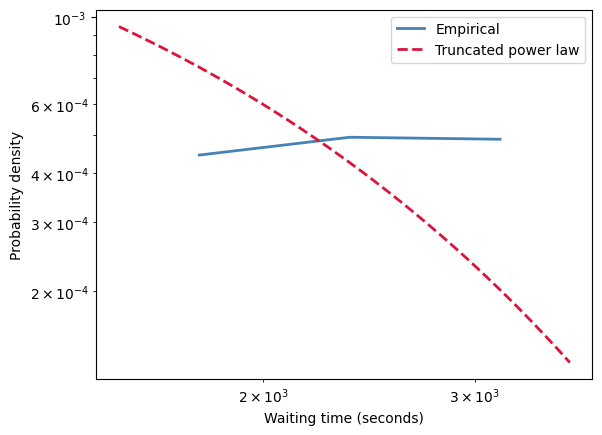

Fitted truncated power law:


In [27]:
import pandas as pd
import powerlaw
import matplotlib.pyplot as plt

# Rebuild a clean copy of the full informative dataset with parsed timestamps
full_inf = df.copy()
full_inf["date_dt"] = pd.to_datetime(full_inf["date"], utc=True, errors="coerce")
full_inf["sender_id"] = pd.to_numeric(full_inf["sender_id"], errors="coerce").astype("Int64")

# Use the matched misinformation rows and go back to the original df rows by id
source_messages = (
    found_inf[["id", "date_dt", "topic_name"]]
    .dropna(subset=["id", "date_dt", "topic_name"])
    .drop_duplicates(subset=["id"])
    .copy()
)

window = pd.Timedelta("60min")
waiting_times_records = []

for _, source in source_messages.iterrows():
    same_topic = full_inf["topic_name"].eq(source["topic_name"])
    within_window = full_inf["date_dt"].gt(source["date_dt"]) & full_inf["date_dt"].le(source["date_dt"] + window)

    later_messages = full_inf.loc[
        same_topic & within_window,
        ["id", "date", "date_dt", "topic_name", "sender_id"]
    ].copy()

    if later_messages.empty:
        continue

    later_messages["source_id"] = source["id"]
    later_messages["source_date_dt"] = source["date_dt"]
    later_messages["wait_seconds"] = (
        later_messages["date_dt"] - source["date_dt"]
    ).dt.total_seconds()

    waiting_times_records.append(later_messages)

if waiting_times_records:
    waiting_times_df = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times = waiting_times_df["wait_seconds"].to_numpy()
    waiting_times = waiting_times[waiting_times > 0]

    print("Number of waiting times:", len(waiting_times))
    print("Min/median/max waiting time (secs):", waiting_times.min(), pd.Series(waiting_times).median(), waiting_times.max())

    fit = powerlaw.Fit(waiting_times, discrete=True, verbose=False)

    ax = fit.plot_pdf(color="steelblue", linewidth=2, label="Empirical")
    fit.truncated_power_law.plot_pdf(ax=ax, color="crimson", linestyle="--", linewidth=2, label="Truncated power law")
    ax.set_xlabel("Waiting time (seconds)")
    ax.set_ylabel("Probability density")
    ax.legend()
    plt.show()

    print("Fitted truncated power law:")
    print(fit.truncated_power_law)
else:
    waiting_times_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
    waiting_times = []
    fit = None
    print("No waiting times were found within the 60-minute window.")

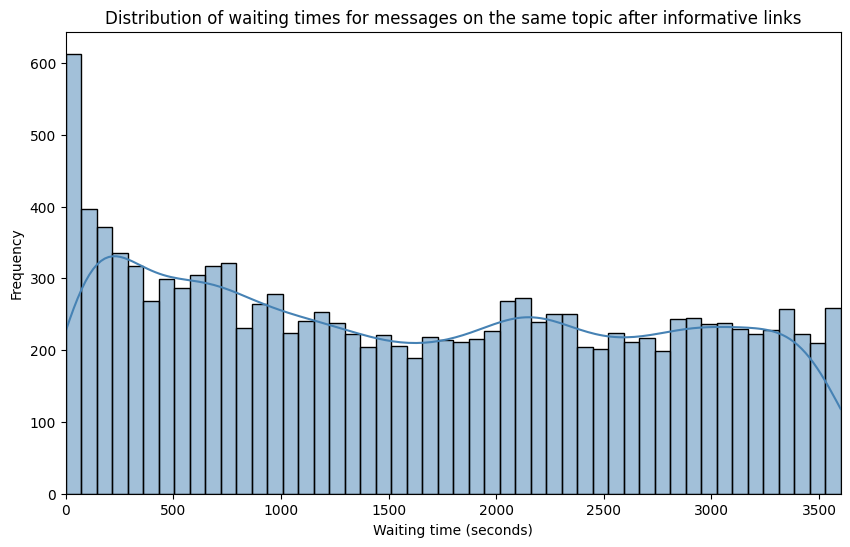

In [35]:
# Obtain the distribution of waiting times
waiting_times = waiting_times_df["wait_seconds"].to_numpy()
waiting_times = waiting_times[waiting_times > 0]
# Plot the distribution of waiting times
plt.figure(figsize=(10, 6))
sns.histplot(waiting_times, bins=50, kde=True, color="steelblue")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of waiting times for messages on the same topic after informative links")
plt.xlim(0, 3600)  # Limit x-axis to 1 hour
plt.show()


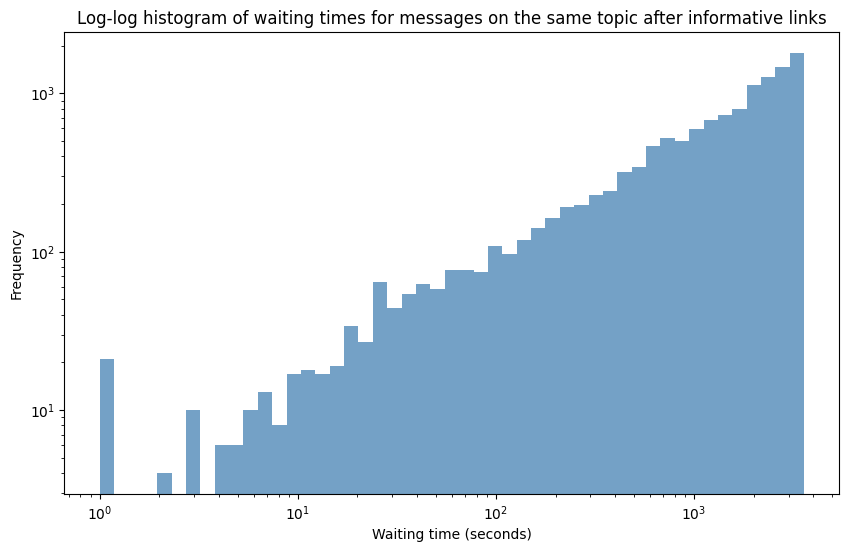

In [36]:
# histogram of waiting times with log-log scale and logarithmic bins
plt.figure(figsize=(10, 6))
bins = np.logspace(np.log10(waiting_times.min()), np.log10(waiting_times.max()), 50)
sns.histplot(waiting_times, bins=bins, kde=False, color="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("Frequency")
plt.title("Log-log histogram of waiting times for messages on the same topic after informative links")
plt.show()  

Misinformation waiting times: 1411
Informative waiting times: 12823


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 0.0000
lambda: 0.000919
xmin: 1427.0000
sigma: nan
Data points above xmin: 773 / 1411 (54.78%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 21.2538, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -6.0560, p = 0.0000
  lognormal is significantly better

Truncated PL vs Exponential:
  R = -0.0289, p = 0.9769
  No significant difference

KS distance (truncated power law): 0.1456
KS p-value (tail): 4.96612e-15


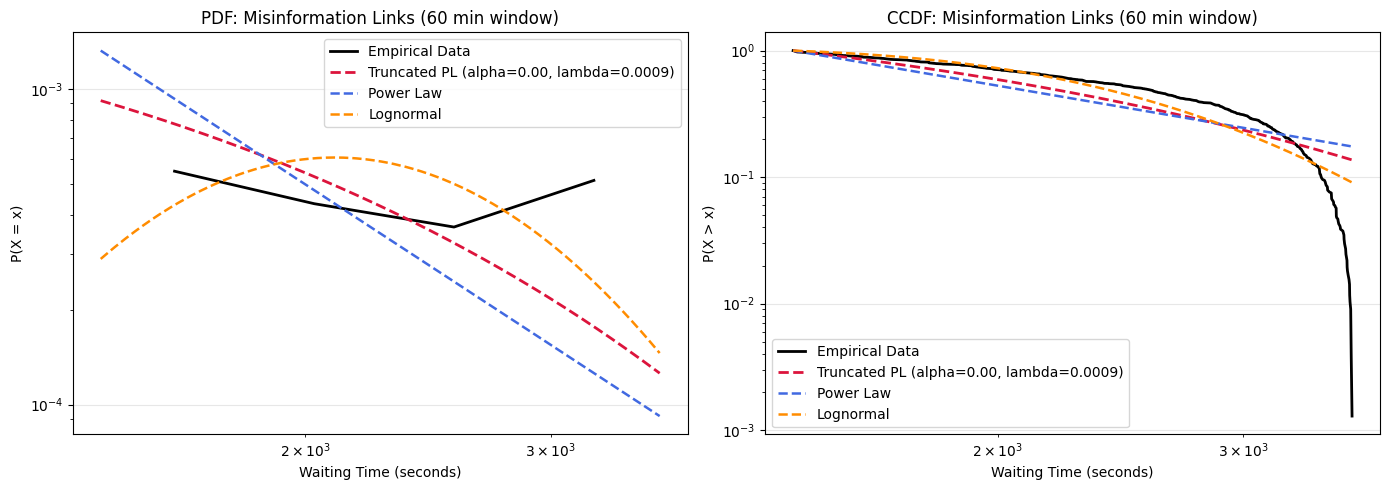

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; cons

TRUNCATED POWER LAW FIT RESULTS: Informative Links (60 min window)
alpha: 0.0000
lambda: 0.000947
xmin: 1516.0000
sigma: nan
Data points above xmin: 6605 / 12823 (51.51%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 78.5951, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -26.3418, p = 0.0000
  lognormal is significantly better

Truncated PL vs Exponential:
  R = -0.0022, p = 0.9983
  No significant difference

KS distance (truncated power law): 0.1576
KS p-value (tail): 4.17929e-144


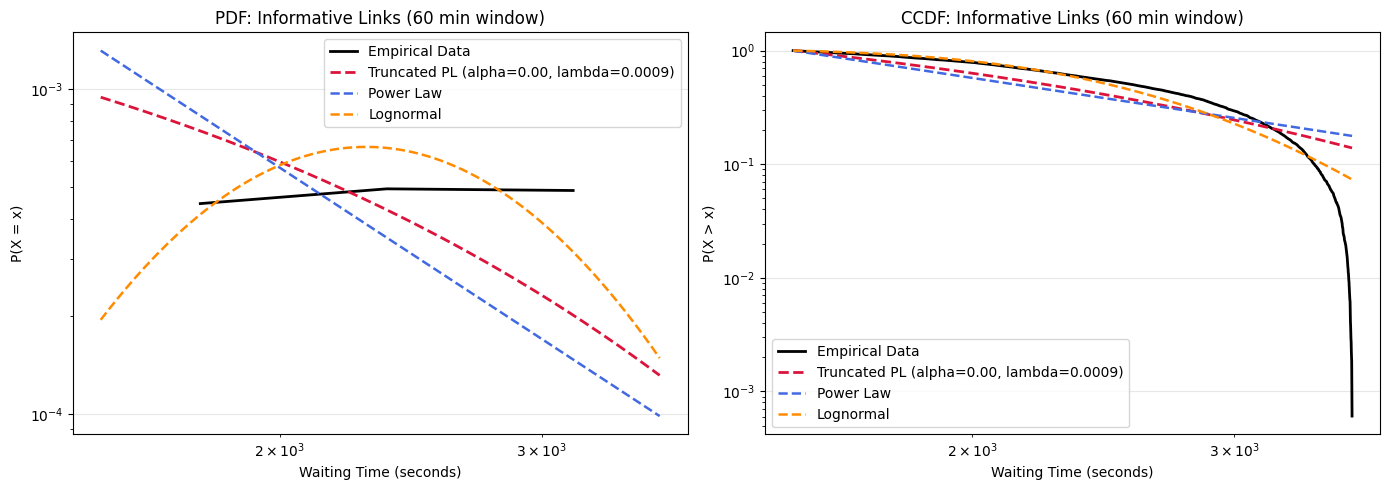

In [30]:
from scipy import stats


def collect_waiting_times_from_found(found_df, full_df, window_minutes=60):
    full_local = full_df.copy()
    full_local["date_dt"] = pd.to_datetime(full_local["date"], utc=True, errors="coerce")
    full_local["sender_id"] = pd.to_numeric(full_local["sender_id"], errors="coerce").astype("Int64")
    full_local = full_local.dropna(subset=["date_dt", "topic_name"])

    source_messages = (
        found_df[["id", "date_dt", "topic_name"]]
        .dropna(subset=["id", "date_dt", "topic_name"])
        .drop_duplicates(subset=["id"])
        .copy()
    )

    window = pd.Timedelta(minutes=window_minutes)
    waiting_times_records = []

    for _, source in source_messages.iterrows():
        same_topic = full_local["topic_name"].eq(source["topic_name"])
        within_window = full_local["date_dt"].gt(source["date_dt"]) & full_local["date_dt"].le(source["date_dt"] + window)

        later_messages = full_local.loc[
            same_topic & within_window,
            ["id", "date", "date_dt", "topic_name", "sender_id"]
        ].copy()

        if later_messages.empty:
            continue

        later_messages["source_id"] = source["id"]
        later_messages["source_date_dt"] = source["date_dt"]
        later_messages["wait_seconds"] = (later_messages["date_dt"] - source["date_dt"]).dt.total_seconds()
        waiting_times_records.append(later_messages)

    if not waiting_times_records:
        empty_df = pd.DataFrame(columns=["id", "date", "date_dt", "topic_name", "sender_id", "source_id", "source_date_dt", "wait_seconds"])
        return empty_df, np.array([])

    waiting_times_df_local = pd.concat(waiting_times_records, ignore_index=True)
    waiting_times_local = waiting_times_df_local["wait_seconds"].to_numpy(dtype=float)
    waiting_times_local = waiting_times_local[np.isfinite(waiting_times_local)]
    waiting_times_local = waiting_times_local[waiting_times_local > 0]

    return waiting_times_df_local, waiting_times_local


def fit_tpl_report(waiting_times_input, label, discrete=True):
    data_tpl = np.asarray(waiting_times_input, dtype=float)
    data_tpl = data_tpl[np.isfinite(data_tpl)]
    data_tpl = data_tpl[data_tpl > 0]

    if len(data_tpl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_tpl)}).")
        print("=" * 70)
        return None

    fit_tpl = powerlaw.Fit(data_tpl, discrete=discrete, verbose=False)
    tpl = fit_tpl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "Lambda", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)

    print("=" * 70)
    print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_tpl:.4f}")
    print(f"lambda: {lambda_tpl:.6f}")
    print(f"xmin: {xmin_tpl:.4f}")
    print(f"sigma: {sigma_tpl:.4f}")
    n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
    print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

    print("\n" + "=" * 70)
    print("TRUNCATED POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
        ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
        ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Truncated power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
    if len(tail_tpl) == 0:
        ks_tpl = float("nan")
        ks_p_tpl = float("nan")
    else:
        empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
        try:
            model_cdf_tpl = tpl.cdf(tail_tpl)
        except Exception:
            model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
        ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
        ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (truncated power law): {ks_tpl:.4f}")
    print(f"KS p-value (tail): {ks_p_tpl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_tpl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    tpl.plot_pdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[0]
    )
    fit_tpl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
    fit_tpl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_tpl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    tpl.plot_ccdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[1]
    )
    fit_tpl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
    fit_tpl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_tpl


# Build waiting times for misinformation and informative links
mis_waiting_df, mis_waiting_times = collect_waiting_times_from_found(found, df, window_minutes=60)
inf_waiting_df, inf_waiting_times = collect_waiting_times_from_found(found_inf, df, window_minutes=60)

print(f"Misinformation waiting times: {len(mis_waiting_times)}")
print(f"Informative waiting times: {len(inf_waiting_times)}")

# Fit both with the same procedure used in temporal_dist_channel
fit_mis = fit_tpl_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)
fit_inf = fit_tpl_report(inf_waiting_times, "Informative Links (60 min window)", discrete=True)

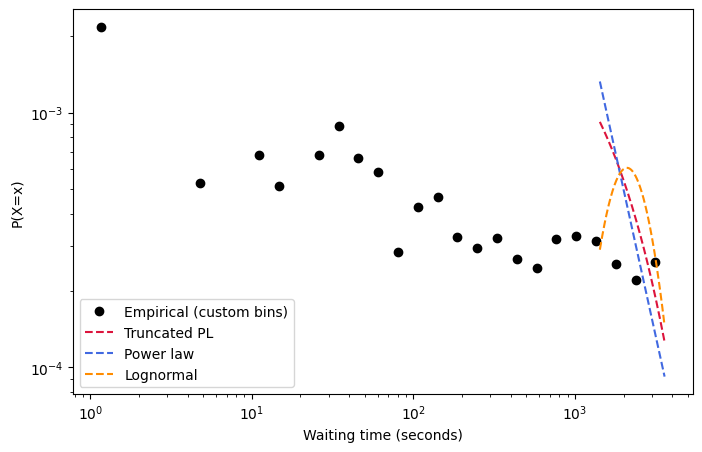

In [31]:
# Empirical PDF with custom bins (more points)
data = np.asarray(mis_waiting_times, dtype=float)
data = data[np.isfinite(data)]
data = data[data > 0]

bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)

plt.figure(figsize=(8,5))
powerlaw.plot_pdf(data, bins=bins, color="black", marker="o", linestyle="none", label="Empirical (custom bins)")
fit_mis.truncated_power_law.plot_pdf(color="crimson", linestyle="--", label="Truncated PL")
fit_mis.power_law.plot_pdf(color="royalblue", linestyle="--", label="Power law")
fit_mis.lognormal.plot_pdf(color="darkorange", linestyle="--", label="Lognormal")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Waiting time (seconds)")
plt.ylabel("P(X=x)")
plt.legend()
plt.show()

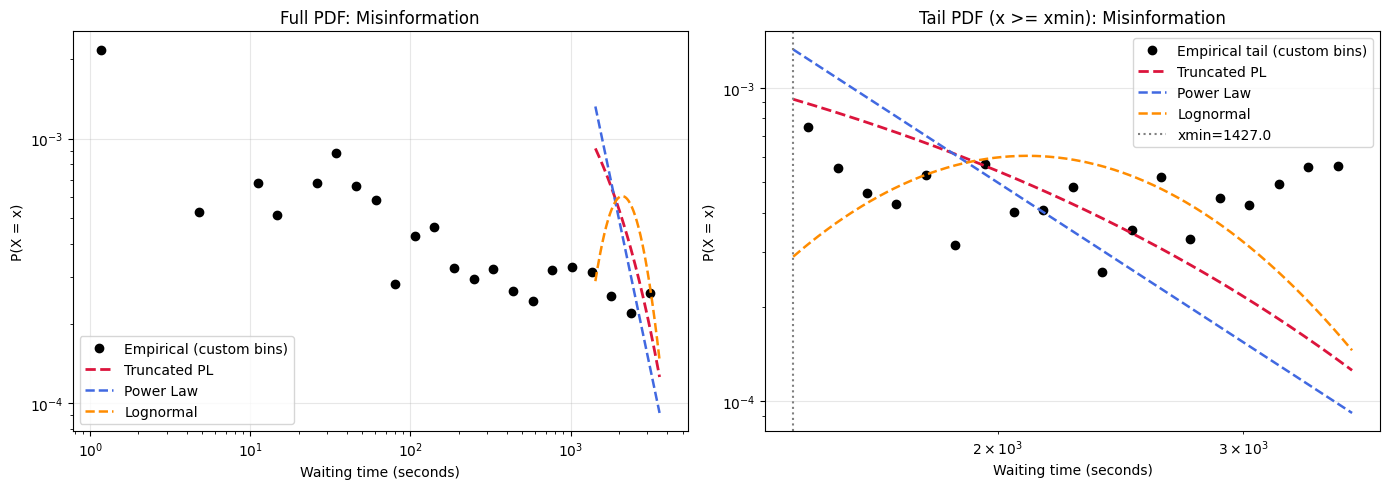

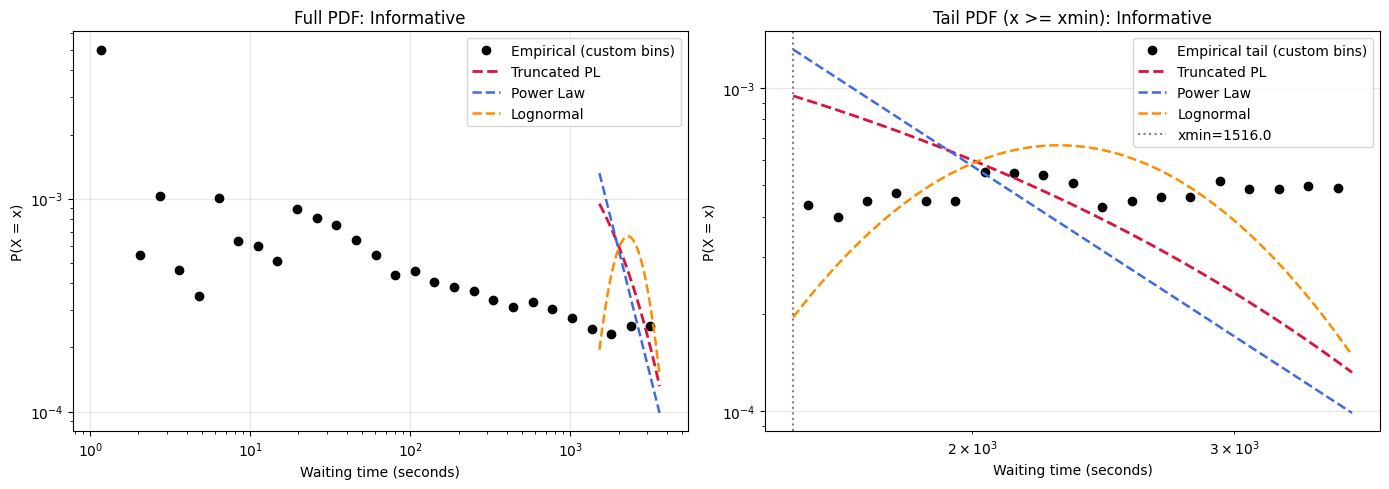

In [33]:
# Full-data vs tail-only PDF (custom bins) for both groups

def plot_full_vs_tail_pdf(data, fit_obj, label, n_bins_full=30, n_bins_tail=20):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    if len(data) < 2 or fit_obj is None:
        print(f"{label}: not enough data to plot.")
        return

    xmin = float(fit_obj.xmin)
    tail = data[data >= xmin]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: full data with custom bins
    bins_full = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins_full)
    powerlaw.plot_pdf(
        data, bins=bins_full, color="black", marker="o", linestyle="none",
        label="Empirical (custom bins)", ax=axes[0]
    )
    fit_obj.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=2, label="Truncated PL", ax=axes[0])
    fit_obj.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
    fit_obj.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Waiting time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"Full PDF: {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: tail only (x >= xmin) with custom bins
    if len(tail) >= 2 and tail.min() < tail.max():
        bins_tail = np.logspace(np.log10(tail.min()), np.log10(tail.max()), n_bins_tail)
        powerlaw.plot_pdf(
            tail, bins=bins_tail, color="black", marker="o", linestyle="none",
            label="Empirical tail (custom bins)", ax=axes[1]
        )
    else:
        axes[1].text(0.5, 0.5, "Not enough tail points", ha="center", va="center", transform=axes[1].transAxes)

    fit_obj.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=2, label="Truncated PL", ax=axes[1])
    fit_obj.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
    fit_obj.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].axvline(xmin, color="gray", linestyle=":", linewidth=1.5, label=f"xmin={xmin:.1f}")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Waiting time (seconds)")
    axes[1].set_ylabel("P(X = x)")
    axes[1].set_title(f"Tail PDF (x >= xmin): {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_full_vs_tail_pdf(mis_waiting_times, fit_mis, "Misinformation")
plot_full_vs_tail_pdf(inf_waiting_times, fit_inf, "Informative")

### Normal Power Law

POWER LAW FIT RESULTS: Misinformation Links (60 min window)
alpha: 2.8899
xmin: 1427.0000
sigma: 0.0680
Data points above xmin: 773 / 1411 (54.78%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -21.2538, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -11.2196, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -21.2341, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.1888
KS p-value (tail): 6.16307e-25


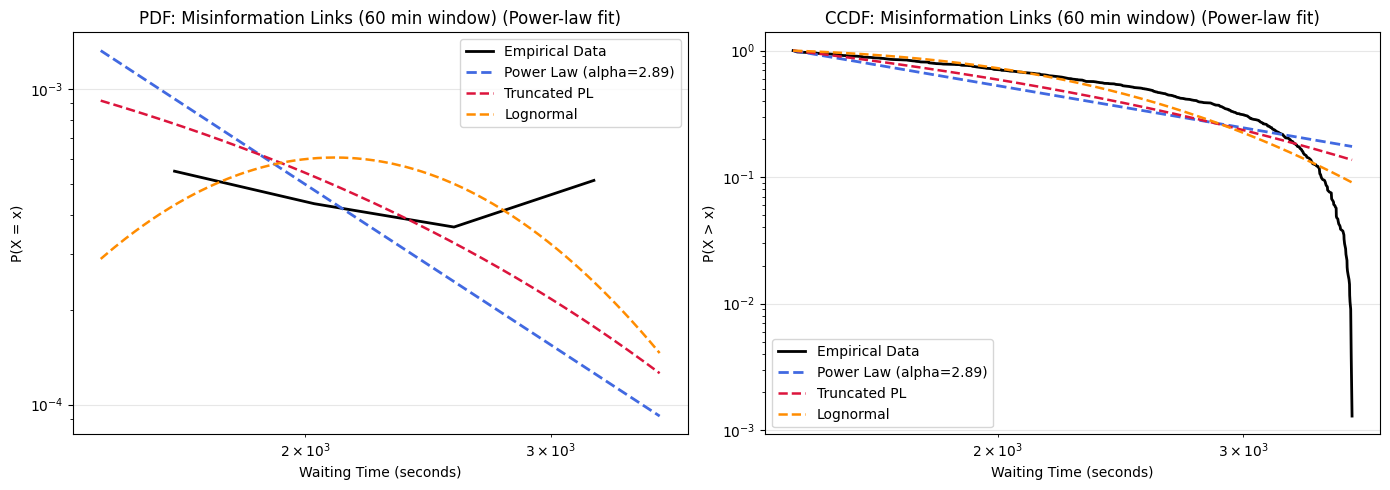

POWER LAW FIT RESULTS: Informative Links (60 min window)
alpha: 2.9991
xmin: 1516.0000
sigma: 0.0246
Data points above xmin: 6605 / 12823 (51.51%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; cons


Power Law vs Truncated PL:
  R = -78.5951, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -40.3226, p = 0.0000
  lognormal is significantly better

Power Law vs Exponential:
  R = -78.5714, p = 0.0000
  exponential is significantly better

KS distance (power law): 0.2140
KS p-value (tail): 2.94296e-266


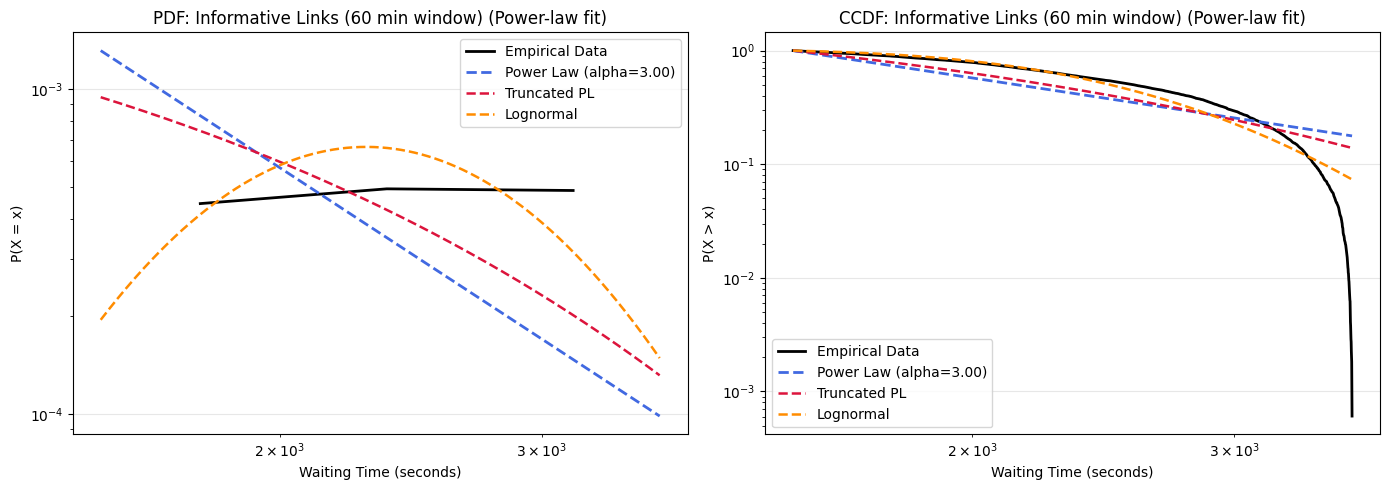

In [34]:
# Plain power-law fit for both groups

def fit_power_law_report(waiting_times_input, label, discrete=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    print("=" * 70)
    print(f"POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_pl:.4f}")
    print(f"xmin: {xmin_pl:.4f}")
    print(f"sigma: {sigma_pl:.4f}")
    n_tail_pl = int(np.sum(data_pl >= xmin_pl))
    print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

    print("\n" + "=" * 70)
    print("POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
        ("power_law", "lognormal", "Power Law vs Lognormal"),
        ("power_law", "exponential", "Power Law vs Exponential"),
    ]

    for d1, d2, cmp_label in comparisons:
        R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
        print(f"\n{cmp_label}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Power law is significantly better")
            else:
                print(f"  {d2.replace('_', ' ')} is significantly better")
        else:
            print("  No significant difference")

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        ks_stat_pl, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (power law): {ks_pl:.4f}")
    print(f"KS p-value (tail): {ks_p_pl:.6g}")
    print("=" * 70)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
    fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
    fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label} (Power-law fit)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
    fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
    fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label} (Power-law fit)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_pl


fit_mis_pl = fit_power_law_report(mis_waiting_times, "Misinformation Links (60 min window)", discrete=True)
fit_inf_pl = fit_power_law_report(inf_waiting_times, "Informative Links (60 min window)", discrete=True)